<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/05_Adult_Census_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💰 Dataset 05: Adult Census Income

## 📋 Descripción del Dataset
Este dataset, también conocido como "Census Income", se utiliza para predecir si una persona gana más de $50,000 al año basándose en datos censales de 1994.
* **Archivo utilizado:** `adult.data`.
* **Objetivo:** Clasificación binaria del ingreso (`income`).
* **Dimensiones:** 32,561 filas y 15 columnas.

## 🛠️ Archivos en esta carpeta
* `adult.data`: Datos de entrenamiento sin cabeceras.
* `adult.names`: Documentación oficial con la descripción de atributos.
* `05_Adult_Census_Analysis.ipynb`: Cuaderno de Colab con el flujo de preparación.

## ⚙️ Trabajo y Preparación de Datos (Preprocesamiento)
1. **Asignación de Headers:** Dado que el archivo original carece de nombres de columnas, se asignaron manualmente según la documentación (`age`, `workclass`, `education`, etc.).
2. **Limpieza de Espacios:** Se utilizó el parámetro `skipinitialspace=True` para eliminar los espacios en blanco iniciales en los valores categóricos.
3. **Manejo de Valores Desconocidos:** Se identificaron valores marcados con `?`, convirtiéndolos a `NaN` y aplicando imputación por la **Moda** (categóricos) y **Media** (numéricos).
4. **Codificación:** Transformación de 9 variables categóricas mediante `LabelEncoder`.
5. **Normalización:** Aplicación de la fórmula `(X - mu) / sigma` para escalar variables de gran rango como `fnlwgt` y `capital-gain`.

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

In [1]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Librerías cargadas correctamente.


In [2]:
# ==============================================================================
# 2. CARGA DE DATOS (Asignación manual de columnas)
# ==============================================================================
# Definimos los nombres de las columnas según la documentación del dataset
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

ruta_adult = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/05_Adult (Census)/adult.data'

# Cargamos el archivo sin cabecera y asignamos los nombres
df = pd.read_csv(ruta_adult, names=columnas, sep=',', skipinitialspace=True)

print("="*70)
print(f"DATASET ADULT CENSUS CARGADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("Objetivo (y): 'income' (Clasificación >50K o <=50K)")
print("="*70)
display(df.head(3))

DATASET ADULT CENSUS CARGADO: 32561 filas y 15 columnas
Objetivo (y): 'income' (Clasificación >50K o <=50K)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [3]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: TRATAMIENTO DE NULOS Y VALORES DESCONOCIDOS
# ==============================================================================
print("="*70)
print(" FASE 1: LIMPIEZA DE DATOS FALTANTES")
print("="*70)

# En este dataset, los nulos están marcados como '?'
# Primero los convertimos a NaN reales para que Pandas los reconozca
df.replace('?', np.nan, inplace=True)

# ANTES
nulos_antes = df.isnull().sum()
print("\n🔴 [ANTES] Valores faltantes detectados (marcados originalmente como '?'):")
print(nulos_antes[nulos_antes > 0])

# PROCESO: Llenar nulos (Moda para categorías, Media para números)
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0])
    else:
        df[columna] = df[columna].fillna(df[columna].mean())

# DESPUÉS
print(f"\n🟢 [DESPUÉS] Total de nulos restantes: {df.isnull().sum().sum()} ✅")

 FASE 1: LIMPIEZA DE DATOS FALTANTES

🔴 [ANTES] Valores faltantes detectados (marcados originalmente como '?'):
workclass         1836
occupation        1843
native-country     583
dtype: int64

🟢 [DESPUÉS] Total de nulos restantes: 0 ✅


In [4]:
# ==============================================================================
# 4. ANTES Y DESPUÉS: CODIFICACIÓN DE TODAS LAS VARIABLES CATEGÓRICAS
# ==============================================================================
print("="*70)
print(" FASE 2: CODIFICACIÓN DE TODAS LAS VARIABLES DE TEXTO")
print("="*70)

# Detectamos automáticamente todas las columnas que son 'object' (texto)
columnas_texto = df.select_dtypes(include=['object']).columns.tolist()

# ANTES: Mostramos el bloque completo original (9 columnas)
print(f"\n🔴 [ANTES] Se detectaron {len(columnas_texto)} columnas con categorías de texto:")
display(df[columnas_texto].head(3))

# PROCESO: Transformación con LabelEncoder
encoder = LabelEncoder()
for columna in columnas_texto:
    df[columna] = encoder.fit_transform(df[columna].astype(str))

# DESPUÉS: Mostramos el bloque completo transformado
print("\n🟢 [DESPUÉS] Todas las columnas categóricas convertidas a números:")
display(df[columnas_texto].head(3))

 FASE 2: CODIFICACIÓN DE TODAS LAS VARIABLES DE TEXTO

🔴 [ANTES] Se detectaron 9 columnas con categorías de texto:


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K



🟢 [DESPUÉS] Todas las columnas categóricas convertidas a números:


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,6,9,4,0,1,4,1,38,0
1,5,9,2,3,0,4,1,38,0
2,3,11,0,5,1,4,1,38,0


In [5]:
# ==============================================================================
# 5. MATRIZ FINAL Y NORMALIZACIÓN (Estilo Ing. Pacheco)
# ==============================================================================
# 'income' es nuestra variable objetivo (y)
X = df.drop('income', axis=1).values
y = df['income'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print("="*70)
print("¡MATRIZ X_norm CREADA EXITOSAMENTE!")
print(f"Forma de X_norm (Características): {X_norm.shape}")
print(f"Forma de y (Objetivo): {y.shape}")
print("="*70)

¡MATRIZ X_norm CREADA EXITOSAMENTE!
Forma de X_norm (Características): (32561, 14)
Forma de y (Objetivo): (32561,)


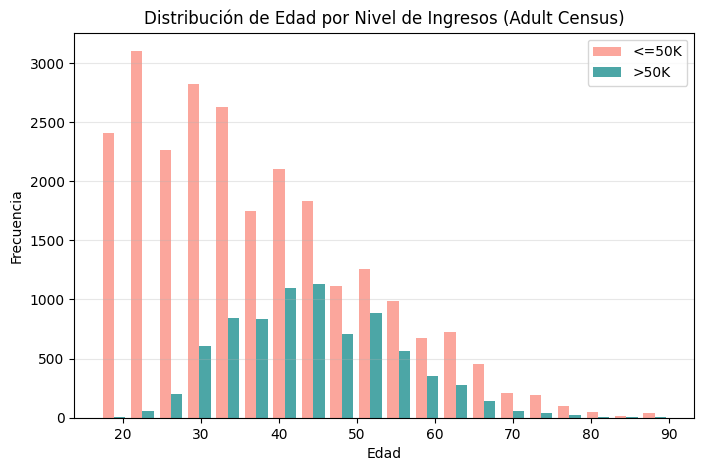

In [6]:
# ==============================================================================
# 6. VISUALIZACIÓN EXPLORATORIA
# ==============================================================================
plt.figure(figsize=(8, 5))
# Graficamos la distribución de edad según el nivel de ingresos
plt.hist([df[df['income'] == 0]['age'], df[df['income'] == 1]['age']],
         bins=20, label=['<=50K', '>50K'], color=['salmon', 'teal'], alpha=0.7)
plt.title('Distribución de Edad por Nivel de Ingresos (Adult Census)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()